# Production Alpha Backtest: Relative Book Strength Strategy

## Executive Summary

This notebook presents a deterministic hold-to-resolution backtest for a token-selection alpha on PMXT market data. The workflow starts from prepared feature shards, compares the UP and DOWN orderbooks within each market, executes with fees and risk constraints, and reports consolidated outcomes.

## Alpha Hypothesis: Why This Can Work (Relative Book Strength)

The strategy assumes that the stronger orderbook within a market carries information about eventual resolution probabilities.
Mechanism behind the edge:
1. **Two competing orderbooks**: UP and DOWN are separate tokens, and we compare them directly within the same market and timestamp.
2. **Relative orderbook strength**: We score each token against its sibling using ask pressure, spread_bps tightness, and depth.
3. **Tight spread_bps filter**: We only act when quoted spread in basis points is tight, reducing stress-regime noise and execution drag.
4. **Token selection**: The token with the stronger relative score is the one we buy.
5. **Confidence ranking**: An action score prioritizes entries with stronger relative book strength and tighter spread_bps context.

## 1) Runtime Setup and Controls

This section initializes project paths, imports the backtesting stack, and defines all run controls.

Controls defined here:
- Data scope and sample size
- Fee model and risk limits
- Action-selection lookahead
- Minimum performance gates (win rate and trade count)

These controls make runs reproducible and keep comparisons fair across threshold variants.

In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt

cwd = Path.cwd().resolve()
if (cwd / "config.py").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "config.py").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise RuntimeError("Could not resolve project root containing config.py")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root configured: {PROJECT_ROOT}")

Project root configured: /Users/rahulthaker/Desktop/onlyPositiveAlpha


In [2]:
from collections.abc import Callable
import importlib
import logging

import pandas as pd
from IPython.display import display as ipy_display
from backtester import BacktestConfig, BacktestRunner
from backtester.config.types import FeatureGatePolicy, ValidationPolicy
import backtester.simulation.analytics as analytics
from utils import setup_application_logging

analytics = importlib.reload(analytics)
MetricsTargets = analytics.MetricsTargets
compute_consolidated_metrics = analytics.compute_consolidated_metrics
print_consolidated_metrics_report = analytics.print_consolidated_metrics_report

setup_application_logging()
logger = logging.getLogger(__name__)

print("Imports complete")

Imports complete


In [3]:
# Runtime configuration (edit only this cell)
RUN_LIMIT_FILES = None
OPTIMIZATION_MARKET_COUNT = 2000
VALIDATION_MARKET_COUNT = 2500
TOTAL_REQUIRED_MARKETS = OPTIMIZATION_MARKET_COUNT + VALIDATION_MARKET_COUNT
MARKET_BATCH_SIZE = 100
USE_FEATURE_CACHE = True

# Hyperparameter optimization controls
HPO_N_TRIALS = 60
HPO_RANDOM_SEED = 42
HPO_MIN_TRADES = 40

# Prepared dataset controls
USE_PREPARED_BACKTEST_DATASET = True
PREPARED_BACKTEST_DATASET_DIR = PROJECT_ROOT / "data" / "cached" / "pmxt_backtest" / "runs" / "btc-updown-5m"
PREPARED_BACKTEST_MANIFEST = PREPARED_BACKTEST_DATASET_DIR / "manifest.json"

# Optional legacy slug prefix filter (ignored when set to None)
MARKET_SLUG_PREFIX: str | None = None

# Optional artifact output
WRITE_ARTIFACT_PACKAGE = True
ARTIFACT_ROOT = PROJECT_ROOT / "reports" / "artifacts"

# Win-rate objective for this workflow
TARGET_WIN_RATE = 0.60

# Fee model
POLYMARKET_FEE_RATES = {
    "crypto": 0.072,
    "sports": 0.03,
    "finance": 0.04,
    "politics": 0.04,
    "economics": 0.05,
    "culture": 0.05,
    "weather": 0.05,
    "other": 0.05,
    "general": 0.05,
    "mentions": 0.04,
    "tech": 0.04,
    "geopolitics": 0.0,
}
FEE_CATEGORY = "crypto"
FEE_RATE_FALLBACK = 0.072
FEE_RATE = POLYMARKET_FEE_RATES.get(FEE_CATEGORY.strip().lower(), FEE_RATE_FALLBACK)
FEES_ENABLED = True
FEE_PRECISION = 5
MIN_FEE = 0.00001

MAPPING_DIR = PROJECT_ROOT / "data" / "cached" / "mapping"

# Position sizing config
# Use capped Kelly so signal_abs can dynamically scale notional by conviction.
SIZING_POLICY = "capped_kelly"  # Options: "risk_budget", "capped_kelly", "fixed_notional"
SIZING_FIXED_NOTIONAL_PCT = 0.01  # Used for "fixed_notional"
AVAILABLE_CAPITAL = 100.0
SIZING_FIXED_NOTIONAL = AVAILABLE_CAPITAL * SIZING_FIXED_NOTIONAL_PCT
SIZING_RISK_BUDGET_PCT = 0.01  # Used for "risk_budget"
SIZING_KELLY_FRACTION_CAP = 0.03  # Used for "capped_kelly"

# Risk constraints calibrated for hold-to-resolution entries.
RISK_MAX_CONCENTRATION_PCT = 1.0
RISK_MAX_ACTIVE_POSITIONS = 100
RISK_MAX_GROSS_EXPOSURE = AVAILABLE_CAPITAL  # Keep gross exposure aligned to available capital (no leverage)

# Helpful visibility into sizing/capacity envelope.
EST_NOTIONAL_PER_TRADE = SIZING_FIXED_NOTIONAL
EST_MAX_CONCURRENT_BY_GROSS = int(RISK_MAX_GROSS_EXPOSURE // max(EST_NOTIONAL_PER_TRADE, 1e-9))
print(
    "Capacity envelope:"
    f" est_notional_per_trade={EST_NOTIONAL_PER_TRADE:.4f},"
    f" est_max_concurrent_by_gross={EST_MAX_CONCURRENT_BY_GROSS},"
    f" active_position_cap={RISK_MAX_ACTIVE_POSITIONS}"
)
print(
    "Market split:"
    f" optimization={OPTIMIZATION_MARKET_COUNT},"
    f" validation={VALIDATION_MARKET_COUNT},"
    f" required_total={TOTAL_REQUIRED_MARKETS}"
)
print(f"HPO controls: trials={HPO_N_TRIALS}, min_trades={HPO_MIN_TRADES}, seed={HPO_RANDOM_SEED}")

BACKTEST_CONFIG = BacktestConfig(
    mode="tolerant",
    shares=1.0,
    validation_policy=ValidationPolicy(),
    feature_gate_policy=FeatureGatePolicy(),
    order_lifecycle_enabled=True,
    order_ttl_seconds=5,
    order_allow_amendments=True,
    order_max_amendments=1,
    risk_max_active_positions=RISK_MAX_ACTIVE_POSITIONS,
    risk_max_concentration_pct=RISK_MAX_CONCENTRATION_PCT,
    risk_max_gross_exposure=RISK_MAX_GROSS_EXPOSURE,
    enable_progress_bars=True,
    metrics_logging_enabled=True,
    metrics_log_every_n_markets=50,
    retain_full_feature_frames=False,
    retain_strategy_signals=True,
    retain_market_events=False,
    sizing_policy=SIZING_POLICY,
    sizing_fixed_notional=SIZING_FIXED_NOTIONAL,
    sizing_risk_budget_pct=SIZING_RISK_BUDGET_PCT,
    sizing_kelly_fraction_cap=SIZING_KELLY_FRACTION_CAP,
    available_capital=AVAILABLE_CAPITAL
)

Capacity envelope: est_notional_per_trade=1.0000, est_max_concurrent_by_gross=100, active_position_cap=100
Market split: optimization=2000, validation=2500, required_total=4500
HPO controls: trials=60, min_trades=40, seed=42


In [4]:
# Threshold and strategy controls: PRODUCTION PRESET (from 2000-market no-shuffle HPO)
# Top validated config: grid_012 (train=1500, validation=500)
# NOTE: when CONFIDENCE_SCORE_MIN <= 1.0, it is interpreted as a quantile cutoff.
RELATIVE_BOOK_SCORE_QUANTILE = 0.60
SPREAD_BPS_NARROW_QUANTILE = 0.10
CONFIDENCE_SCORE_MIN = 0.60
MIN_LIQUIDITY = 0.20
BUY_PRICE_MAX = 0.85

# Time filter policy: allow any entry as long as it is <= max time to resolution.
MIN_TIME_TO_RESOLUTION_SECS = None
MAX_TIME_TO_RESOLUTION_SECS = 180

# Existing pre-trade guardrail from filter discovery.
ASK_DEPTH_5_MAX_FILTER = 881.518

# Dynamic sizing controls from winner/loser diagnostics.
DYNAMIC_POSITION_SIZING = True
DYNAMIC_ASK_DEPTH_5_REF = 1105.44
DYNAMIC_MID_PRICE_REF = 0.75

RELATIVE_PRESSURE_WEIGHT = 0.45
RELATIVE_SPREAD_WEIGHT = 0.35
RELATIVE_DEPTH_WEIGHT = 0.15
RELATIVE_IMBALANCE_WEIGHT = 0.05

print("Active strategy controls (HPO winner preset):")
print(f"  RELATIVE_BOOK_SCORE_QUANTILE={RELATIVE_BOOK_SCORE_QUANTILE}")
print(f"  SPREAD_BPS_NARROW_QUANTILE={SPREAD_BPS_NARROW_QUANTILE}")
print(f"  CONFIDENCE_SCORE_MIN={CONFIDENCE_SCORE_MIN}")
print(f"  BUY_PRICE_MAX={BUY_PRICE_MAX}")
print(f"  MIN_TIME_TO_RESOLUTION_SECS={MIN_TIME_TO_RESOLUTION_SECS}")
print(f"  MAX_TIME_TO_RESOLUTION_SECS={MAX_TIME_TO_RESOLUTION_SECS}")
print(f"  ASK_DEPTH_5_MAX_FILTER={ASK_DEPTH_5_MAX_FILTER}")
print(f"  DYNAMIC_POSITION_SIZING={DYNAMIC_POSITION_SIZING}")
print(f"  DYNAMIC_ASK_DEPTH_5_REF={DYNAMIC_ASK_DEPTH_5_REF}")
print(f"  DYNAMIC_MID_PRICE_REF={DYNAMIC_MID_PRICE_REF}")
if MAX_TIME_TO_RESOLUTION_SECS is not None:
    print(f"  Entry rule: time_to_resolution_secs <= {MAX_TIME_TO_RESOLUTION_SECS}")

Active strategy controls (HPO winner preset):
  RELATIVE_BOOK_SCORE_QUANTILE=0.6
  SPREAD_BPS_NARROW_QUANTILE=0.1
  CONFIDENCE_SCORE_MIN=0.6
  BUY_PRICE_MAX=0.85
  MIN_TIME_TO_RESOLUTION_SECS=None
  MAX_TIME_TO_RESOLUTION_SECS=180
  ASK_DEPTH_5_MAX_FILTER=881.518
  DYNAMIC_POSITION_SIZING=True
  DYNAMIC_ASK_DEPTH_5_REF=1105.44
  DYNAMIC_MID_PRICE_REF=0.75
  Entry rule: time_to_resolution_secs <= 180


## 2) Data Loading and Strategy Construction

This section moves from prepared data to executable strategy logic.

Flow:
1. Load deterministic market universe from prepared PMXT shards.
2. Build token-local narrow-spread ask-pressure signals from each orderbook independently.
3. Instantiate the production strategy with fixed thresholds.
4. Execute one full backtest run with risk and fee controls enabled.

In [5]:
from pathlib import Path

storage_path = PREPARED_BACKTEST_DATASET_DIR
if not storage_path.exists():
    raise FileNotFoundError(f"Storage path not found: {storage_path}")

runner = BacktestRunner(storage_path=storage_path)
# Prepared shards keep PMXT schema even though the directory name is pmxt_backtest.
runner.is_pmxt_mode = True
manifest_path: Path | None = None
if PREPARED_BACKTEST_MANIFEST.exists():
    manifest_path = PREPARED_BACKTEST_MANIFEST

print(f"Storage path: {storage_path}")
print(f"Manifest path: {manifest_path}")
print(f"Optimization market count: {OPTIMIZATION_MARKET_COUNT}")
print(f"Validation market count: {VALIDATION_MARKET_COUNT}")

all_markets = runner.load_prepared_feature_market_ids(
    limit_files=RUN_LIMIT_FILES,
    features_manifest_path=manifest_path,
    recursive_scan=True,
)
if not all_markets:
    raise RuntimeError(
        "Prepared feature dataset returned no market IDs. Rebuild prepared dataset first."
    )

if len(all_markets) < TOTAL_REQUIRED_MARKETS:
    raise RuntimeError(
        f"Only {len(all_markets)} markets available, below required count {TOTAL_REQUIRED_MARKETS}"
    )

optimization_market_ids = all_markets[:OPTIMIZATION_MARKET_COUNT]
validation_market_ids = all_markets[
    OPTIMIZATION_MARKET_COUNT:OPTIMIZATION_MARKET_COUNT + VALIDATION_MARKET_COUNT
]
optimization_market_id_set = set(optimization_market_ids)
validation_market_id_set = set(validation_market_ids)

if optimization_market_id_set & validation_market_id_set:
    raise RuntimeError("Optimization and validation market sets overlap; expected disjoint sets")

print(f"Prepared markets discovered: {len(all_markets)}")
print(f"Optimization markets selected: {len(optimization_market_ids)}")
print(f"Validation markets selected: {len(validation_market_ids)}")
print(f"Optimization sample (first 10): {optimization_market_ids[:10]}")
print(f"Validation sample (first 10): {validation_market_ids[:10]}")

2026-04-08 23:55:03 - backtester.runner - INFO - Initialized BacktestRunner with storage path: /Users/rahulthaker/Desktop/onlyPositiveAlpha/data/cached/pmxt_backtest/runs/btc-updown-5m
2026-04-08 23:55:03 - backtester.runner - INFO - Market event path: /Users/rahulthaker/Desktop/onlyPositiveAlpha/data/cached/pmxt_backtest/runs/btc-updown-5m
2026-04-08 23:55:03 - backtester.runner - INFO - Mapping path: /Users/rahulthaker/Desktop/onlyPositiveAlpha/data/cached/pmxt_backtest/runs/mapping
2026-04-08 23:55:03 - backtester.runner - INFO - Feature cache directory: /Users/rahulthaker/Desktop/onlyPositiveAlpha/data/cached/pmxt_backtest/runs/feature_cache
2026-04-08 23:55:03 - backtester.runner - INFO - PMXT mode: False


Storage path: /Users/rahulthaker/Desktop/onlyPositiveAlpha/data/cached/pmxt_backtest/runs/btc-updown-5m
Manifest path: /Users/rahulthaker/Desktop/onlyPositiveAlpha/data/cached/pmxt_backtest/runs/btc-updown-5m/manifest.json
Optimization market count: 2000
Validation market count: 2500
Prepared markets discovered: 4595
Optimization markets selected: 2000
Validation markets selected: 2500
Optimization sample (first 10): ['0x001c0a542548d0aa8eacfcd07b8dc6e467aabfeb2c3d548f2099a48e357f686d', '0x001dd28330f9787319a1ce1e8b06116a736e01964bb3e4ea67f51e087b69d414', '0x00246a314b8e6671b54cf6e4cfd73c77e3e8c9da3d177381c782acfa903bd181', '0x00254c7cb78deef428f8c2228fa88f9ba23c8ebfdebf26100dccd77fdcda5165', '0x002f9eaa33c6c9d04c1f232acbd1801b6de20769f271a99fce3fc32c9430f936', '0x0048018784542fd8ebd2749f681d9bb4bc530a78b817870643f196478567bbc8', '0x004aff5c484213e8101fc6421b55f585987433e4a958d498bda42271d7b3ef6f', '0x00589896a44527e4d919abe008b8906a3ee5376075ebe6bb3ca5a749d5aaac49', '0x006c587eea49e31

In [6]:
# Regime awareness is intentionally disabled for now.
regime_csv_path = None
regime_df = pd.DataFrame(columns=["timestamp", "regime"])
regime_lookup = {}
regimes_unique = []

print("Regime awareness: DISABLED (plain global HPO mode)")

Regime awareness: DISABLED (plain global HPO mode)


### Strategy Intuition: Compare the Two Books

**Simple idea**: each market has two tokens, UP and DOWN. Each token has its own orderbook. This strategy compares those two books at the same time and buys the token that looks stronger.

What “stronger” means here:
- The book has more buying support than selling pressure.
- The spread is tight, so the trade is cheaper to enter.
- The book has enough depth, so the quote looks more reliable.
- The token has a better score than its sibling token in the same market.

How the strategy works:
1. Look at UP and DOWN in the same market and timestamp.
2. Score both tokens using spread, depth, and book pressure.
3. Buy the token with the higher score.
4. Skip the trade if the edge is not strong enough.

The goal is to trade only when one side of the market looks clearly better, not to force a trade every time.

In [7]:
from alphas.cumulative_relative_book_strength import (
    StrategyParams as CumulativeRelativeBookStrengthParams,
    build_relative_book_strength_strategy as build_cumulative_relative_book_strength_strategy,

)
def build_relative_book_strength_strategy(
    *,
    relative_book_score_quantile: float,
    spread_bps_narrow_quantile: float,
    confidence_score_min: float,
    min_liquidity: float,
    buy_price_max: float | None = None,
    min_time_to_resolution_secs: float | None = None,
    max_time_to_resolution_secs: float | None = None,
    ask_depth_5_max_filter: float | None = None,
    dynamic_position_sizing: bool = False,
    dynamic_ask_depth_5_ref: float | None = None,
    dynamic_mid_price_ref: float | None = None,
    signal_abs_scale: float = 0.01,
    pressure_weight: float = 0.45,
    spread_weight: float = 0.35,
    depth_weight: float = 0.15,
    imbalance_weight: float = 0.05,
    use_cumulative_signal: bool = True,
    cumulative_signal_mode: str = "ewm",
    cumulative_signal_alpha: float = 0.20,
) -> Callable[[pd.DataFrame], pd.DataFrame]:
    """Compatibility wrapper around the shared cumulative relative-book alpha module."""

    _ = signal_abs_scale  # signal_abs scaling is managed inside the shared strategy implementation.

    params = CumulativeRelativeBookStrengthParams(
        relative_book_score_quantile=relative_book_score_quantile,
        spread_bps_narrow_quantile=spread_bps_narrow_quantile,
        confidence_score_min=confidence_score_min,
        min_liquidity=min_liquidity,
        buy_price_max=buy_price_max,
        min_time_to_resolution_secs=min_time_to_resolution_secs,
        max_time_to_resolution_secs=max_time_to_resolution_secs,
        ask_depth_5_max_filter=ask_depth_5_max_filter,
        dynamic_position_sizing=dynamic_position_sizing,
        dynamic_ask_depth_5_ref=dynamic_ask_depth_5_ref,
        dynamic_mid_price_ref=dynamic_mid_price_ref,
        use_cumulative_signal=use_cumulative_signal,
        cumulative_signal_mode=cumulative_signal_mode,
        cumulative_signal_alpha=cumulative_signal_alpha,
        pressure_weight=pressure_weight,
        spread_weight=spread_weight,
        depth_weight=depth_weight,
        imbalance_weight=imbalance_weight,
    )

    return build_cumulative_relative_book_strength_strategy(
        params=params,
        enable_spread_gate=True,
        enable_score_gate=True,
        enable_score_gap_gate=True,
        enable_price_cap_gate=True,
        enable_liquidity_gate=True,
        enable_ask_depth_5_cap_gate=True,
        enable_time_gate=True,
    )

### Forward Test on Unseen Markets

Using the winning preset from the 1000-market HPO run (from `scripts/diagnose_relative_book_strategy.py`):
- **Candidate**: candidate_2_high_winrate
- **Sample**: 3000 new markets (beyond the 1000 used for HPO)
- **Expected performance**: 809 trades, 76.76% win_rate, +26.83 net_pnl (from HPO validation)

In [8]:
# Forward test: next 3000 markets (unseen, beyond HPO optimization set)
# Using winner preset: candidate_2_high_winrate
print(f"\n{'='*80}")
print("FORWARD TEST: NEXT 3000 MARKETS (UNSEEN BY HPO)")
print(f"{'='*80}")
print(f"HPO used: {OPTIMIZATION_MARKET_COUNT} markets")
print(f"Forward test uses: {VALIDATION_MARKET_COUNT} new markets")
print("Winner preset: candidate_2_high_winrate")
print(f"  • spread_bps_narrow_quantile={SPREAD_BPS_NARROW_QUANTILE}")
print(f"  • confidence_score_min={CONFIDENCE_SCORE_MIN}")
print(f"  • relative_book_score_quantile={RELATIVE_BOOK_SCORE_QUANTILE}")
print(f"  • buy_price_max={BUY_PRICE_MAX}")
print(f"  • max_time_to_resolution_secs={MAX_TIME_TO_RESOLUTION_SECS}")

forward_strategy = build_relative_book_strength_strategy(
    relative_book_score_quantile=RELATIVE_BOOK_SCORE_QUANTILE,
    spread_bps_narrow_quantile=SPREAD_BPS_NARROW_QUANTILE,
    confidence_score_min=CONFIDENCE_SCORE_MIN,
    min_liquidity=MIN_LIQUIDITY,
    buy_price_max=BUY_PRICE_MAX,
    min_time_to_resolution_secs=MIN_TIME_TO_RESOLUTION_SECS,
    max_time_to_resolution_secs=MAX_TIME_TO_RESOLUTION_SECS,
    ask_depth_5_max_filter=ASK_DEPTH_5_MAX_FILTER,
    dynamic_position_sizing=DYNAMIC_POSITION_SIZING,
    dynamic_ask_depth_5_ref=DYNAMIC_ASK_DEPTH_5_REF,
    dynamic_mid_price_ref=DYNAMIC_MID_PRICE_REF,
    signal_abs_scale=1.0 if DYNAMIC_POSITION_SIZING else 0.01,
    pressure_weight=RELATIVE_PRESSURE_WEIGHT,
    spread_weight=RELATIVE_SPREAD_WEIGHT,
    depth_weight=RELATIVE_DEPTH_WEIGHT,
    imbalance_weight=RELATIVE_IMBALANCE_WEIGHT,
)

print(f"\nRunning forward test on {len(validation_market_id_set)} unseen markets...")
forward_result = runner.run_backtest(
    mapping_dir=MAPPING_DIR,
    prepared_manifest_path=manifest_path,
    strategy=forward_strategy,
    strategy_name="relative_book_strength_forward_test",
    limit_files=RUN_LIMIT_FILES,
    market_slug_prefix=MARKET_SLUG_PREFIX,
    market_batch_size=MARKET_BATCH_SIZE,
    prepared_feature_market_ids=validation_market_id_set,
    config=BACKTEST_CONFIG,
)

artifact_package_dir = None
if WRITE_ARTIFACT_PACKAGE:
    artifact_package_dir = runner.write_run_artifact_package(
        forward_result,
        output_dir=ARTIFACT_ROOT,
        artifact_version="forward_test_3000m",
    )

print("\n" + "="*80)
print("FORWARD TEST COMPLETE")
print("="*80)
if not forward_result.backtest_summary.empty:
    summary_row = forward_result.backtest_summary.iloc[0]
    print(f"Run ID: {forward_result.metadata.run_id}")
    print(f"Markets tested: {len(validation_market_id_set)}")
    print(f"Trades: {int(summary_row['trades'])}")
    print(f"Win Rate: {float(summary_row['win_rate']):.2%}")
    print(f"Net PnL: {float(summary_row['net_pnl']):.4f}")
    print(f"Gross PnL: {float(summary_row['gross_pnl']):.4f}")
    if 'fees' in summary_row:
        print(f"Fees: {float(summary_row['fees']):.4f}")
else:
    print("ERROR: empty result summary")
if artifact_package_dir is not None:
    print(f"Artifact package: {artifact_package_dir}")

2026-04-08 23:55:03 - backtester.runner_pipeline - INFO - Backtest batch mode enabled: strategies=1 batch_size=100
2026-04-08 23:55:03 - backtester.runner_pipeline - INFO - Backtest resolution (batch mode): markets=4595 diagnostics_rows=0 elapsed=0.01s



FORWARD TEST: NEXT 3000 MARKETS (UNSEEN BY HPO)
HPO used: 2000 markets
Forward test uses: 2500 new markets
Winner preset: candidate_2_high_winrate
  • spread_bps_narrow_quantile=0.1
  • confidence_score_min=0.6
  • relative_book_score_quantile=0.6
  • buy_price_max=0.85
  • max_time_to_resolution_secs=180

Running forward test on 2500 unseen markets...


backtest: market batches:   0%|          | 0/25 [00:00<?, ?batch/s]2026-04-08 23:55:04 - backtester.loaders.runner_core - INFO - Loaded 615132 prepared feature rows
2026-04-08 23:55:04 - backtester.runner_support - INFO - Trimmed post-resolution rows before feature gates: events=748 across 16 markets, features=748 across 16 markets
2026-04-08 23:55:10 - backtester.simulation.execution_engine - INFO - Backtest market progress [relative_book_strength_forward_test]: 50/91 markets | trades=50 | eligible=50 | risk_reject=0 | fill_reject=0 | fill_rate=100.00% | net_pnl=6.247580
2026-04-08 23:55:10 - backtester.simulation.execution_engine - INFO - Backtest market progress [relative_book_strength_forward_test]: 91/91 markets | trades=91 | eligible=91 | risk_reject=0 | fill_reject=0 | fill_rate=100.00% | net_pnl=12.191064
2026-04-08 23:55:10 - backtester.simulation.execution_engine - INFO - Backtest market summary [relative_book_strength_forward_test]: markets=91 resolved=91 eligible=91 trades=


FORWARD TEST COMPLETE
Run ID: f68372e58bdc436b9037a183e69379ba
Markets tested: 2500
Trades: 1838
Win Rate: 80.63%
Net PnL: -6.7667
Gross PnL: 26.3540
Fees: 33.1207
Artifact package: /Users/rahulthaker/Desktop/onlyPositiveAlpha/reports/artifacts/forward_test_3000m/f68372e58bdc436b9037a183e69379ba


## 3) Primary Results and Quality Checks

The next output cell reports the main ledgers and headline metrics for go/no-go assessment.

Interpretation guide:
- **Trades**: verifies enough observations for a meaningful estimate.
- **Win rate vs target**: checks directional hit quality against the minimum bar.
- **Net PnL**: confirms whether edge survives fees and execution costs.
- **Data quality and error ledgers**: ensures performance is not driven by silent data defects.

If win rate clears target but net PnL is weak, inspect payoff skew, fee drag, and position sizing before accepting the result.

In [9]:
resolution_frame = forward_result.resolution_frame
resolution_diagnostics = forward_result.resolution_diagnostics
trade_ledger = forward_result.trade_ledger
order_ledger = forward_result.order_ledger
backtest_summary = forward_result.backtest_summary
equity_curve = forward_result.equity_curve
strategy_signals = forward_result.strategy_signals
feature_health = forward_result.feature_health
data_quality_report = forward_result.data_quality_report
error_ledger = forward_result.error_ledger
settlement_repair_audit = forward_result.settlement_repair_audit
diagnostics_by_market = forward_result.diagnostics_by_market
cache_metadata = forward_result.cache_metadata

if trade_ledger.empty:
    raise RuntimeError(
        "No trades were generated. Relax thresholds, expand lookback, or verify mapping coverage."
    )

strategy_name = backtest_summary.iloc[0]["strategy"]
strategy_signal_frame = strategy_signals[strategy_name]
win_rate = float(backtest_summary.iloc[0]["win_rate"])
trades = int(backtest_summary.iloc[0]["trades"])
net_pnl = float(backtest_summary.iloc[0]["net_pnl"])

print(f"Strategy: {strategy_name}")
print(f"Resolved markets available: {len(resolution_frame)}")
print(f"Validated markets: {len(resolution_diagnostics)}")
print(f"Generated {len(trade_ledger)} closed trades")
print(f"Win rate: {win_rate:.1%} across {trades} trades")
print(f"Net PnL: {net_pnl:.4f}")
print(f"Cache metadata: {cache_metadata}")
print(f"Data quality issues: {len(data_quality_report)}")
print(f"Feature health rows: {len(feature_health)}")
print(f"Error ledger rows: {len(error_ledger)}")
print(f"Settlement repair audit rows: {len(settlement_repair_audit)}")

if net_pnl <= 0.0:
    print(
        f"WARNING: Net PnL {net_pnl:.4f} is non-positive. Recalibrate threshold grid or fill assumptions."
    )
if win_rate < TARGET_WIN_RATE:
    print(
        f"WARNING: Win rate {win_rate:.1%} is below target {TARGET_WIN_RATE:.0%}. "
        "Adjust fixed strategy thresholds or match target to current market conditions."
    )

ipy_display(backtest_summary)

Strategy: relative_book_strength_forward_test
Resolved markets available: 4595
Validated markets: 0
Generated 1838 closed trades
Win rate: 80.6% across 1838 trades
Net PnL: -6.7667
Cache metadata: {'cache_signature': 'bff9cb90f0c8e0f8', 'cache_schema_version': 'v1', 'cache_computation_signature': 'orderbook_core_v1'}
Data quality issues: 0
Feature health rows: 200
Error ledger rows: 16
Settlement repair audit rows: 0


,strategy,trades,wins,win_rate,gross_pnl,net_pnl,fees,avg_gross_pnl,avg_net_pnl,avg_hold_hours,avg_gross_return_pct,avg_net_return_pct,fee_drag_pct,run_id
0,relative_book_strength_forward_test,1838,1482,0.806311,26.353962,-6.766738,33.1207,0.014338,-0.003682,0.029149,0.010439,-0.004086,0.014887,f68372e58bdc436b9037a183e69379ba


In [10]:
print("\n" + "=" * 80)
print("DEBUG: Check time-to-resolution filter application")
print("=" * 80)

if "time_to_resolution_secs" in strategy_signal_frame.columns:
    print("\n✓ time_to_resolution_secs column found in signals")
    time_col = strategy_signal_frame["time_to_resolution_secs"]
    print(f"\nSignal statistics:")
    print(f"  Total signals: {len(time_col)}")
    print(f"  Mean: {time_col.mean():.1f}s | Median: {time_col.median():.1f}s")
    print(f"  Min: {time_col.min():.1f}s | Max: {time_col.max():.1f}s")

    in_window = pd.Series(True, index=time_col.index)
    if MIN_TIME_TO_RESOLUTION_SECS is not None:
        in_window &= time_col >= MIN_TIME_TO_RESOLUTION_SECS
    if MAX_TIME_TO_RESOLUTION_SECS is not None:
        in_window &= time_col <= MAX_TIME_TO_RESOLUTION_SECS

    in_count = int(in_window.sum())
    out_count = int(len(time_col) - in_count)
    print("\nConfigured window check:")
    print(f"  MIN_TIME_TO_RESOLUTION_SECS={MIN_TIME_TO_RESOLUTION_SECS}")
    print(f"  MAX_TIME_TO_RESOLUTION_SECS={MAX_TIME_TO_RESOLUTION_SECS}")
    print(f"  Signals in configured window: {in_count} ({in_count/len(time_col)*100:.1f}%)")
    print(f"  Signals outside window: {out_count}")

    if out_count > 0:
        print("\nExample outside-window signal times:")
        print(time_col[~in_window].head(10).to_list())
else:
    print("\n✗ time_to_resolution_secs NOT found in signals")
    print("  Time filter cannot be validated.")


DEBUG: Check time-to-resolution filter application

✓ time_to_resolution_secs column found in signals

Signal statistics:
  Total signals: 42679
  Mean: 79.4s | Median: 71.6s
  Min: 0.0s | Max: 180.0s

Configured window check:
  MIN_TIME_TO_RESOLUTION_SECS=None
  MAX_TIME_TO_RESOLUTION_SECS=180
  Signals in configured window: 42679 (100.0%)
  Signals outside window: 0


In [11]:
print("\n" + "=" * 80)
print("PAYOFF ASYMMETRY ANALYSIS - Gross vs Net Breakdown")
print("=" * 80)

trade_diag = trade_ledger[trade_ledger["net_pnl"].notna()].copy()

# Determine which PnL columns exist
has_gross = "gross_pnl" in trade_diag.columns
has_net = "net_pnl" in trade_diag.columns
has_fees = "fees" in trade_diag.columns

print(f"\nAvailable columns: gross_pnl={has_gross}, net_pnl={has_net}, fees={has_fees}")
print(f"Total trades: {len(trade_diag)}")

# Use net_pnl if available, otherwise fall back to gross_pnl
pnl_col = "net_pnl" if has_net else "gross_pnl"
if pnl_col not in trade_diag.columns:
    print("ERROR: Neither net_pnl nor gross_pnl found in trade ledger")
else:
    winners = trade_diag[trade_diag[pnl_col] > 0]
    losers = trade_diag[trade_diag[pnl_col] < 0]
    
    trades_count = len(trade_diag)
    win_count = len(winners)
    lose_count = len(losers)
    actual_win_rate = win_count / trades_count if trades_count > 0 else 0
    
    avg_win = winners[pnl_col].mean() if len(winners) > 0 else 0
    avg_loss = abs(losers[pnl_col].mean()) if len(losers) > 0 else 0
    
    print(f"\n├─ Using column: {pnl_col}")
    print(f"├─ Trades: {trades_count} | Winners: {win_count} | Losers: {lose_count}")
    print(f"└─ Actual win rate: {actual_win_rate:.2%}")
    
    print(f"\nPayoff (per trade, {pnl_col}):")
    print(f"  Average winner:   ${avg_win:>8.6f}")
    print(f"  Average loser:    ${avg_loss:>8.6f}")
    if avg_win > 1e-9:
        print(f"  Ratio (loss/win): {avg_loss/avg_win:>8.2f}x")
    
    # If we have gross_pnl, also show that breakdown
    if has_gross and pnl_col == "net_pnl":
        winners_gross = winners["gross_pnl"].mean() if len(winners) > 0 else 0
        losers_gross = abs(losers["gross_pnl"].mean()) if len(losers) > 0 else 0
        
        print(f"\nPayoff breakdown (gross_pnl):")
        print(f"  Average winner (gross):   ${winners_gross:>8.6f}")
        print(f"  Average loser (gross):    ${losers_gross:>8.6f}")
        
        # Fee impact
        if len(winners) > 0:
            fees_on_winners = (winners["gross_pnl"] - winners["net_pnl"]).mean() if "fees" in trade_diag.columns else 0
            print(f"\n  Avg fees on winners: ${fees_on_winners:.6f}")
        if len(losers) > 0:
            fees_on_losers = (losers["gross_pnl"].abs() - losers["net_pnl"].abs()).mean() if "fees" in trade_diag.columns else 0
            print(f"  Avg fees on losers:  ${fees_on_losers:.6f}")
    
    # Calculate breakeven
    if (avg_win + avg_loss) > 1e-9:
        implied_breakeven_win_rate = avg_loss / (avg_win + avg_loss)
    else:
        implied_breakeven_win_rate = 0.5
    
    print(f"\nBreakeven analysis:")
    print(f"  Implied breakeven rate: {implied_breakeven_win_rate:.2%}")
    print(f"  Actual win rate:        {actual_win_rate:.2%}")
    print(f"  Gap:                    {(actual_win_rate - implied_breakeven_win_rate):.2%}")
    
    if (avg_win + avg_loss) > 1e-9:
        total_pnl_from_payoff = (win_count * avg_win) - (lose_count * avg_loss)
        print(f"\nExpected gross from payoff structure: ${total_pnl_from_payoff:.4f}")
        if has_gross:
            actual_gross = trade_diag["gross_pnl"].sum()
            print(f"Actual gross from ledger:            ${actual_gross:.4f}")
            print(f"Difference:                          ${(total_pnl_from_payoff - actual_gross):.4f}")

print("\n" + "=" * 80)


PAYOFF ASYMMETRY ANALYSIS - Gross vs Net Breakdown

Available columns: gross_pnl=True, net_pnl=True, fees=False
Total trades: 1838

├─ Using column: net_pnl
├─ Trades: 1838 | Winners: 1482 | Losers: 356
└─ Actual win rate: 80.63%

Payoff (per trade, net_pnl):
  Average winner:   $0.296739
  Average loser:    $1.254310
  Ratio (loss/win):     4.23x

Payoff breakdown (gross_pnl):
  Average winner (gross):   $0.314584
  Average loser (gross):    $1.235562

  Avg fees on winners: $0.000000
  Avg fees on losers:  $0.000000

Breakeven analysis:
  Implied breakeven rate: 80.87%
  Actual win rate:        80.63%
  Gap:                    -0.24%

Expected gross from payoff structure: $-6.7667
Actual gross from ledger:            $26.3540
Difference:                          $-33.1207



## 4) Consolidated Performance and Risk Interpretation

This section is the portfolio-level checkpoint, not just a strategy snapshot.

How to read the outputs:
- **Consolidated metrics table**: headline risk-return profile.
- **Validation checks table**: pass/fail against explicit minimum standards.
- **Order state table**: operational health and execution realism.
- **Capital curve and per-trade PnL**: path dependency, drawdowns, and stability.

If the alpha is robust, improvements should appear jointly in win rate quality, drawdown behavior, and post-fee capital trajectory, not in a single metric only.

FINAL CONSOLIDATED METRICS

Consolidated metrics table:


,strategy,trades,wins,win_rate,gross_pnl,net_pnl,fees,avg_gross_pnl,avg_net_pnl,avg_hold_hours,...,total_return_pct,sharpe_ratio,sortino_ratio,max_drawdown_pct,calmar_ratio,num_trades,win_rate_pct,profit_factor,initial_capital,final_capital
0,relative_book_strength_forward_test,1838,1482,0.8063,26.354,-6.7667,33.1207,0.0143,-0.0037,0.0291,...,-6.7667,-0.0766,-0.1069,-25.3603,-0.2668,1838,80.6311,0.9848,100.0,93.2333



Validation checks table:


,strategy,check,passed,value
0,relative_book_strength_forward_test,trades >= 0,True,1838.000000
1,relative_book_strength_forward_test,win_rate >= 60%,True,0.806311
2,relative_book_strength_forward_test,sharpe >= 0.5,False,-0.076603
3,relative_book_strength_forward_test,abs(max_drawdown_pct) <= 25.0,False,-25.360307
4,relative_book_strength_forward_test,capital_preserved > 50,True,93.233262



Order state table:


,state,count
0,submitted,1838
1,filled,1838


Downsampled capital plot for relative_book_strength_forward_test: 1838 -> 919 points


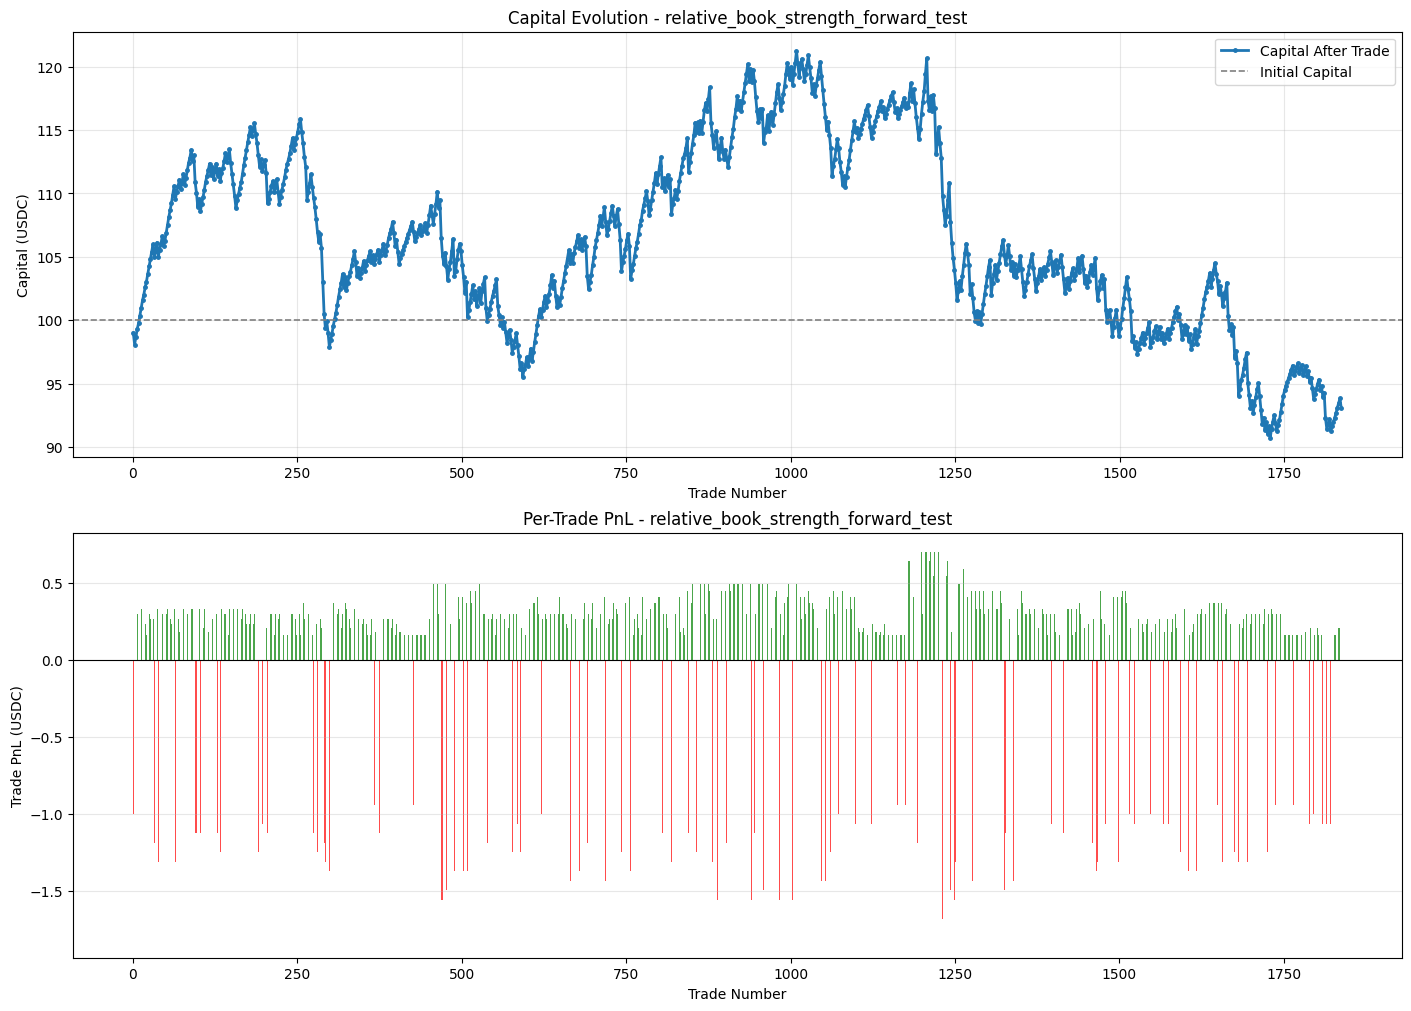

In [12]:
import math

print("=" * 80)
print("FINAL CONSOLIDATED METRICS")
print("=" * 80)

initial_capital = float(getattr(BACKTEST_CONFIG, "available_capital", None) or 100.0)
plot_max_points = 1200

metrics_bundle = compute_consolidated_metrics(
    backtest_summary=backtest_summary,
    trade_ledger=trade_ledger,
    order_ledger=order_ledger,
    equity_curve=equity_curve,
    initial_capital=initial_capital,
    targets=MetricsTargets(
        min_trades=0,
        min_win_rate=0.60,
        min_sharpe=0.5,
        max_drawdown_pct=25.0,
    ),
)

consolidated_metrics = metrics_bundle["consolidated_metrics"]
validation_checks = metrics_bundle["validation_checks"]
capital_evolution_df = metrics_bundle["capital_evolution"]
order_state = metrics_bundle["order_state"]

if not consolidated_metrics.empty:
    print("\nConsolidated metrics table:")
    ipy_display(consolidated_metrics.round(4))

if not validation_checks.empty:
    print("\nValidation checks table:")
    ipy_display(validation_checks)

if not order_state.empty:
    print("\nOrder state table:")
    ipy_display(order_state)

if not capital_evolution_df.empty:
    for strategy_name in capital_evolution_df["strategy"].dropna().unique().tolist():
        strategy_capital = capital_evolution_df[
            capital_evolution_df["strategy"] == strategy_name
        ].copy()
        strategy_capital = strategy_capital.sort_values("trade_num")

        plot_capital = strategy_capital
        if len(strategy_capital) > plot_max_points:
            step = max(1, math.ceil(len(strategy_capital) / plot_max_points))
            plot_capital = strategy_capital.iloc[::step].copy()
            print(
                f"Downsampled capital plot for {strategy_name}: "
                f"{len(strategy_capital)} -> {len(plot_capital)} points"
            )

        fig, axes = plt.subplots(2, 1, figsize=(14, 10), constrained_layout=True)

        ax1 = axes[0]
        ax1.plot(
            plot_capital["trade_num"],
            plot_capital["post_trade_capital"],
            label="Capital After Trade",
            linewidth=2.0,
            marker="o",
            markersize=2.5,
        )
        ax1.axhline(
            y=initial_capital,
            color="gray",
            linestyle="--",
            linewidth=1.2,
            label="Initial Capital",
        )
        ax1.set_xlabel("Trade Number")
        ax1.set_ylabel("Capital (USDC)")
        ax1.set_title(f"Capital Evolution - {strategy_name}")
        ax1.grid(True, alpha=0.3)
        ax1.legend(loc="best")

        ax2 = axes[1]
        bar_colors = [
            "green" if pnl > 0 else "red"
            for pnl in plot_capital["net_pnl"].tolist()
        ]
        ax2.bar(
            plot_capital["trade_num"],
            plot_capital["net_pnl"],
            color=bar_colors,
            alpha=0.7,
        )
        ax2.axhline(y=0.0, color="black", linestyle="-", linewidth=0.8)
        ax2.set_xlabel("Trade Number")
        ax2.set_ylabel("Trade PnL (USDC)")
        ax2.set_title(f"Per-Trade PnL - {strategy_name}")
        ax2.grid(True, alpha=0.3, axis="y")

        plt.show()
        plt.close(fig)